# Time-series Prediction

A time series is a sequence of observations, ordered in time. Forecasting involves training a model on historical data and using them to predict future observations. A simple example is a linear auto-regressive model. The linear auto-regressive (AR) model of a time-series $Z_t$ with $t=1,2,\dots,\infty$ is given by

$$\hat{z}_t = a_1 z_{t-1} + a_2 z_{t-2} + \cdots + a_p z_{t-p},$$

with $a_i \in \mathbb{R}$ for $i=1, \dots, p$ and $p$ the model lag. The prediction for a certain time $t$ is equal to a weighted sum of the previous values up to a certain lag $p$. In a similar way, the nonlinear (NAR) variant is described as

$$\hat{z}_t = f(z_{t-1}, z_{t-2}, \dots, z_{t-p}).$$

The figure below visualizes this process.

<img src="https://raw.githubusercontent.com/KULasagna/ANN_DL_public/master/assets/nar.jpg" width="600">

Remark that in this way, the time-series identification can be written as a classical black-box regression modeling problem $\hat{y}_t=f(x_t)$ with $y_t=z_t$ and $x_t=[z_{t-1}, z_{t-2}, \dots, z_{t-p}]$. When preparing the dataset and applying train/validation/test splits, it is important to prevent *data leakage* by respecting the temporal information flow. More precisely, a datapoint $z_t$ should not be part of two splits &mdash; either as input $x_t$ or target $y_t$ &mdash; and training (or validation) sets should not contain datapoints that occur after test datapoints.

In this notebook, we work on the time-series prediction problem using a multilayer perceptron (MLP) and a long short-term memory network (LSTM).

## Colab Setup
This part is only required when running this notebook "in the cloud" on [Google Colab](https://colab.research.google.com). When running it locally, skip this part and go to the next section.

In [ ]:
# Load some auxiliary files from github.
!wget https://raw.githubusercontent.com/KULasagna/ANN_DL_public/master/session2/SantaFe.npz

## Setup
Import all the necessary modules used throughout this notebook and define some helper methods to work with timeseries data and visualize the results.

In [ ]:
# Import the required modules for this notebook
from dataclasses import dataclass
import keras
import matplotlib.pyplot as plt
import numpy as np
import scipy
from sklearn.model_selection import TimeSeriesSplit

In [ ]:
@dataclass
class Fold:
  train_idxs: np.ndarray
  val_idxs: np.ndarray

def prepare_timeseries(timeseries, lag, validation_size=0, validation_folds=0):
  # Generate train (and validation) sets for the given timeseries and lag
  data = scipy.linalg.hankel(timeseries[:-lag], timeseries[-lag-1:-1])
  targets = timeseries[lag:]
  if validation_size > 0 and validation_folds > 0:
    tss = TimeSeriesSplit(test_size=validation_size, gap=lag)
    tss.n_splits = validation_folds
    folds = [Fold(train_idxs, val_idxs) for (train_idxs, val_idxs) in tss.split(data)]
    return data, targets, folds
  return data, targets

def shift(window, values):
  # Append new values to the given window (dropping the oldest values)
  result = np.empty(window.shape)
  values = np.atleast_1d(values)
  s = values.shape[0]
  result[:-s] = window[s:]
  result[-s:] = values
  return result

def normalize(timeseries, params=None):
  # Apply z-score normalization to the given timeseries
  if params is None:
    params = (np.mean(timeseries), np.std(timeseries))
  mu, sigma = params
  normalized = (timeseries - mu) / sigma
  return normalized, params

def rescale(timeseries, params):
  # Rescale the normalized timeseries back to its original values
  mu, sigma = params
  rescaled = mu + timeseries * sigma
  return rescaled

In [ ]:
def plot_history(history, title, filename=None):
  # Plot the train and validation loss curves
  fig, ax = plt.subplots(figsize=(10, 3))
  ax.semilogy(history.history['loss'], label='Train')
  if 'val_loss' in history.history:
    ax.semilogy(history.history['val_loss'], label='Validation')
  ax.legend()
  ax.set_xlabel('Epochs')
  ax.set_ylabel('Loss')
  plt.title(title)
  if filename is not None:
    plt.savefig(f"{filename}.svg")
  plt.show()

def plot_timeseries(timeseries_dict, title, filename=None):
  # Plot the given timeseries
  fig, ax = plt.subplots(figsize=(10, 3))
  for label, (start, ts) in timeseries_dict.items():
    ax.plot(start + np.arange(len(ts)), ts, label=label)
  ax.legend()
  ax.set_xlabel('Timestep')
  ax.set_ylabel('Laser intensity')
  plt.title(title)
  if filename is not None:
    plt.savefig(f"{filename}.svg")
  plt.show()

## Santa Fe Laser Dataset
The Santa Fe laser dataset is obtained from a chaotic laser which can be described as a nonlinear dynamical system. The first $1000$ data points can be used for training and validation purposes. The aim is to predict the next $100$ points (it is forbidden to include these points in the training or validation sets!). Both datasets are stored in the `SantaFe.npz` file and are visualized below.

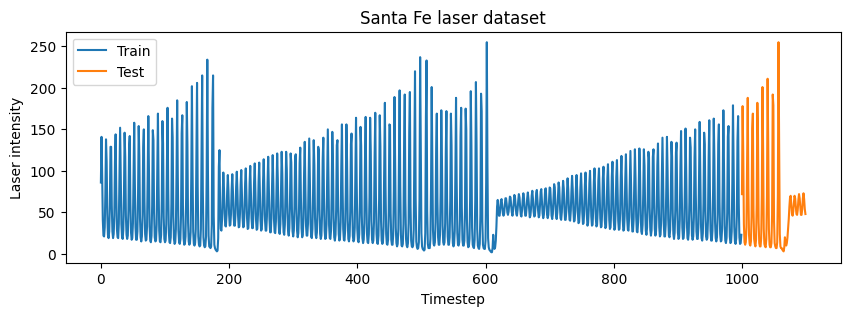

In [ ]:
santafe = np.load('SantaFe.npz')
train_series = santafe['A']
test_series = santafe['Acont']
plot_timeseries({
    'Train': (0, train_series),
    'Test': (len(train_series), test_series)
}, 'Santa Fe laser dataset')

To train the various nonlinear autoregressive models, it will be useful to prepare the timeseries dataset beforehand. We start by normalizing the train and test sets.

In [ ]:
normalized, params = normalize(santafe['A'])
normalized_test, _ = normalize(santafe['Acont'], params)

Next, the `prepare_timeseries` function is used to convert the timeseries into training data ($x_t$) and targets ($y_t$). Make sure you understand what the function does by trying it out on a small toy example.

In [ ]:
timeseries = np.arange(10)  # Increase this number to create a larger time series
lag = 3  # Try different values for the lag
data, targets, folds = prepare_timeseries(timeseries, lag, validation_size=1, validation_folds=2)  # Examine the effect of the validation size and number of validation folds
print(f"Original timeseries: {timeseries}")
print(f"Data for lag {lag}: {data}")
print(f"Targets: {targets}")
for i, fold in enumerate(folds):
  print(f"Fold {i}:")
  print(f"  Train:     data={data[fold.train_idxs]}, targets={targets[fold.train_idxs]}")
  print(f"  Validate:  data={data[fold.val_idxs]}, targets={targets[fold.val_idxs]}")

Original timeseries: [0 1 2 3 4 5 6 7 8 9]
Data for lag 3: [[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]
 [4 5 6]
 [5 6 7]
 [6 7 8]]
Targets: [3 4 5 6 7 8 9]
Fold 0:
  Train:     data=[[0 1 2]
 [1 2 3]], targets=[3 4]
  Validate:  data=[[5 6 7]], targets=[8]
Fold 1:
  Train:     data=[[0 1 2]
 [1 2 3]
 [2 3 4]], targets=[3 4 5]
  Validate:  data=[[6 7 8]], targets=[9]


Once you understand the dataset structure, apply it to the normalized Santa Fe timeseries. You can come back to these cells later to change the values of the lag or validation parameters.

In [ ]:
# @title Parameters { run: "auto" }
lag = 10 # @param {type:"slider", min:1, max:100, step:1}
validation_size = 100 # @param {type:"slider", min:10, max:200, step:1}
validation_folds = 4 # @param {type:"slider", min:1, max:10, step:1}
# This is the hidden dimension of the MLP and LSTM networks trained later in this notebook
H = 20 # @param {type:"slider", min:10, max:100, step:1}

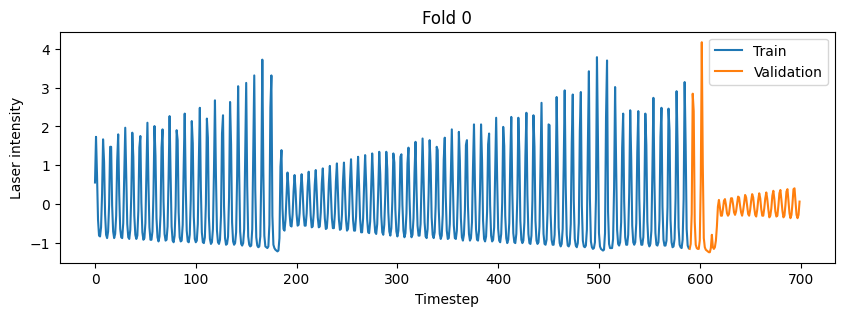

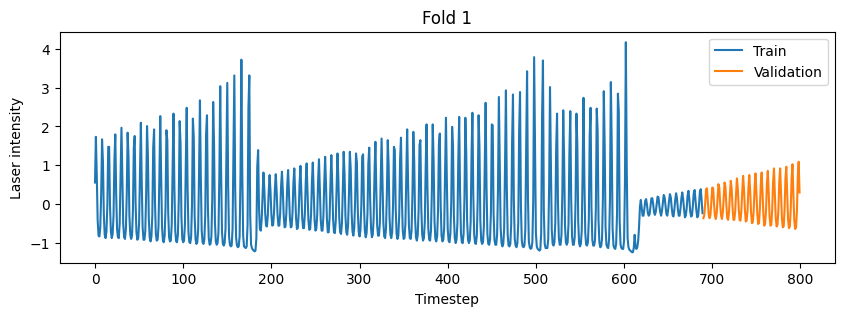

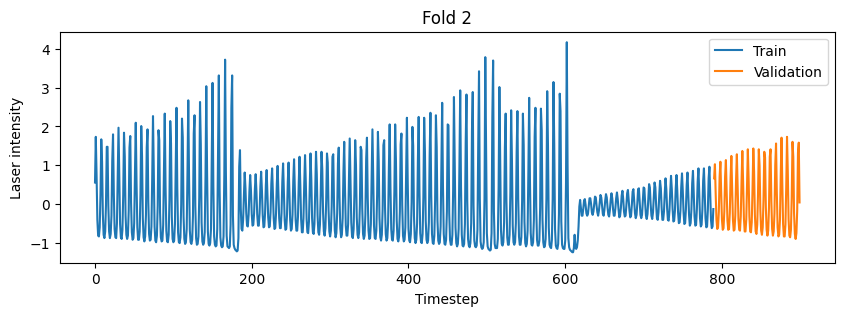

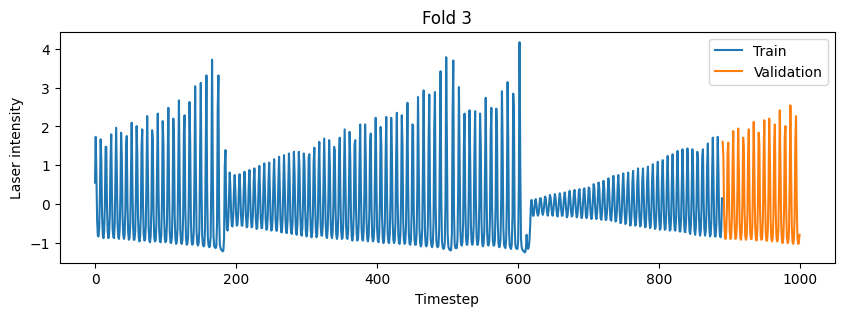

In [ ]:
data, targets, folds = prepare_timeseries(normalized, lag, validation_size, validation_folds)
# Plot train and validation data for each fold:
for f, fold in enumerate(folds):
  train_series = np.concatenate([data[fold.train_idxs[0]], targets[fold.train_idxs]])
  val_series = np.concatenate([data[fold.val_idxs[0]], targets[fold.val_idxs]])
  plot_timeseries({"Train": (0, train_series), "Validation": (len(train_series), val_series)}, f"Fold {f}")

## MLP
We now train a first nonlinear autoregressive (NAR) model on the training set and choose the hyperparameters based on the predictive performance on the validation sets. This first model is a multilayer perceptron (MLP) and training is done in feedforward mode using the prepared training set

$$\hat{z}_t = w^\top \tanh(V[z_{t-1}; z_{t-2}; \dots; z_{t-p}] + \beta).$$

In order to make predictions, the trained network is used in an iterative way as a recurrent network

$$\hat{z}_t = w^\top \tanh(V[\hat{z}_{t-1}; \hat{z}_{t-2}; \dots; \hat{z}_{t-p}] + \beta).$$

In [ ]:
# Define the MLP network architecture
def MLP(input_dim, hidden_dim, output_dim, activation='tanh'):
  return keras.Sequential([
    keras.layers.Input(shape=[input_dim]),  # Expect input of shape (B, I) with B batch size, I input size
    keras.layers.Dense(units=hidden_dim, activation=activation),  # Output of shape (B, H) with H hidden feature size
    keras.layers.Dense(units=output_dim)  # Output of shape (B, O) with O output size
  ])

Train the MLP on the last training fold. You can later put this code in a `for` loop to train on each of the training folds for determining the optimal hyperparameters using $N$-fold cross-validation.

In [ ]:
net = MLP(lag, H, 1)
net.compile(
  loss=keras.losses.MeanSquaredError(),
  optimizer=keras.optimizers.Adam(learning_rate=0.01)
)
fold = folds[-1]
history = net.fit(data[fold.train_idxs], targets[fold.train_idxs],
                  validation_data=(data[fold.val_idxs], targets[fold.val_idxs]),
                  epochs=200, verbose=0)

Plot the train and validation loss curves.

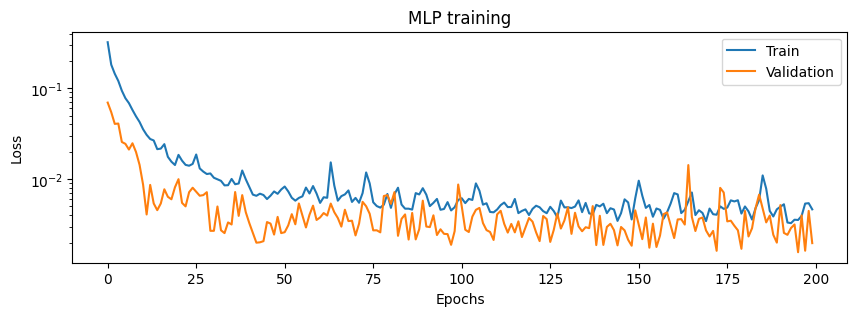

In [ ]:
plot_history(history, "MLP training")

### **Exercise 1**
Investigate the model performance with different lags and number of neurons. Discuss how the model looks and explain clearly how you tune the parameters and what the influence on the final prediction is. Which combination of parameters gives the best performance (MSE) on the test set?

The MSE on the test set is: 2710.635


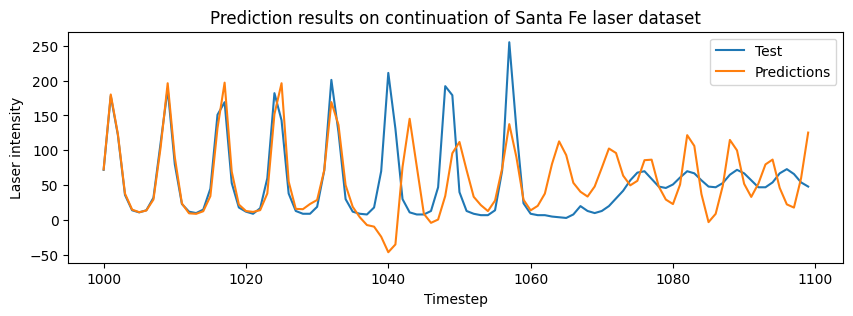

In [ ]:
# Evaluation on test set
test_data = shift(data[-1], targets[-1])
predictions = np.empty(normalized_test.shape)
for t in range(len(predictions)):
  predictions[t] = net.predict(test_data.reshape((1, lag)), verbose=0).squeeze()
  test_data = shift(test_data, predictions[t])

# Rescale predictions
predictions_mlp = rescale(predictions, params)

# Compute the mean squared error between the predictions and test set
mse = np.mean((test_series - predictions_mlp)**2)
print("The MSE on the test set is: {:.3f}".format(mse))

# Plot
plot_timeseries({"Test": (1000, test_series), "Predictions": (1000, predictions_mlp)}, "MLP prediction results on continuation of Santa Fe laser dataset")

### @solution
The results can vary a lot depending on the random initialization of the network. $2$-fold cross-validation with a validation size of $200$ or $4$-fold cross-validation with a validation size of $100$ (such that there is a 'drop' in one of the validation sets), can lead to good values for the lag and number of neurons. For example $lag=30$ and $H=30$ typically lead to satisfying predictions for the MLP (it can never accurately predict values past the 'drop'), though results vary a lot and other combinations might provide equally good results.

In [ ]:
# Untested N-cross validation code (took 1h30 for 4 folds of size 100 with 5 repeats on Matlab)
lags = np.arange(20, 61, 10)
Hs = np.arange(20, 61, 10)
repeats = 5
validation_size = 100
validation_folds = 4
vperf = np.infty*np.ones((len(lags), len(Hs), repeats, validation_folds))
for l, lag in enumerate(lags):
  data, targets, folds = prepare_timeseries(normalized, lag, validation_size, validation_folds)
  for h, H in enumerate(Hs):
    print(f"Training with lag={lag} and H={H}")
    for r in range(repeats):
      for f, fold in enumerate(folds):
        net = MLP(lag, H, 1)
        net.compile(
          loss=keras.losses.MeanSquaredError(),
          optimizer=keras.optimizers.Adam(learning_rate=0.01)
        )
        history = net.fit(data[fold.train_idxs], targets[fold.train_idxs],
                  validation_data=(data[fold.val_idxs], targets[fold.val_idxs]),
                  epochs=200, verbose=0)
        vperf[l, h, r, f] = np.min(history.history["val_loss"])

In [ ]:
# Determine best parameters
mean_vperf = np.mean(vperf, axis=(2, 3))
best_l, best_h = np.unravel_index(np.argmin(mean_vperf), mean_vperf.shape)
best_lag = lags[best_l]
best_H = Hs[best_h]
print(f"Best validation performance for lag={best_lag} and H={best_H}: {mean_vperf[best_l, best_h]}")
# Plot mean validation performance
# imagesc(mean_vperf)

The MSE on the test set is: 750.859


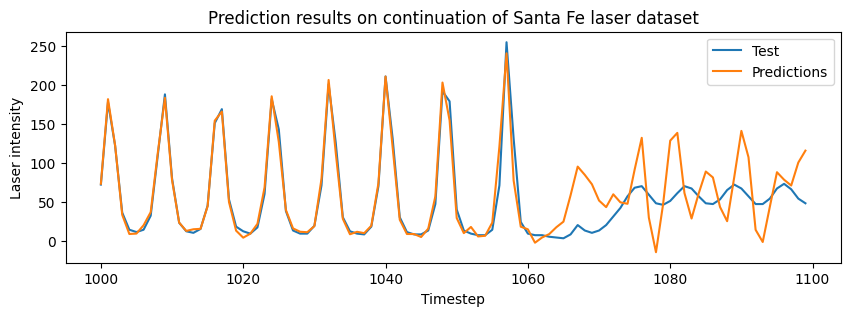

In [ ]:
# Train using "best" hyperparameters; multiple retries might be needed as each run differs quite a lot.
lag, H = 30, 30
data, targets = prepare_timeseries(normalized, lag)
best_mlp = MLP(lag, H, 1)
best_mlp.compile(
  loss=keras.losses.MeanSquaredError(),
  optimizer=keras.optimizers.Adam(learning_rate=0.01)
)
best_mlp.fit(data, targets, epochs=200, verbose=0)

# Evaluation on test set
test_data = shift(data[-1], targets[-1])
predictions = np.empty(normalized_test.shape)
for t in range(len(predictions)):
  predictions[t] = best_mlp.predict(test_data.reshape((1, lag)), verbose=0).squeeze()
  test_data = shift(test_data, predictions[t])

# Rescale predictions
predictions_mlp = rescale(predictions, params)

# Compute the mean squared error between the predictions and test set
mse = np.mean((test_series - predictions_mlp)**2)
print("The MSE on the test set is: {:.3f}".format(mse))

# Plot
plot_timeseries({"Test": (1000, test_series), "Predictions": (1000, predictions_mlp)}, "Prediction results on continuation of Santa Fe laser dataset")

## LSTM
We now train the second model, which is a Long Short Term Memory (LSTM) network. These are a special kind of RNN, capable of learning long-term dependencies. LSTMs contain information outside the normal flow of the recurrent network in a gated cell. Information can be stored in, written to, or read from a cell, much like data in a computer's memory. The cell makes decisions about what to store and when to allow reads, writes and erasures, via gates that open and close. Those gates act on the signals they receive, and similar to the neural network's nodes, they block or pass on information based on its strength and importance, which they filter with their own sets of weights. Those weights, like the weights that modulate input and hidden states, are adjusted via the recurrent network's learning process. That is, the cells learn when to allow data to enter, leave or be deleted through the iterative process of making guesses, backpropagating the error, and adjusting weights via gradient descent.

In [ ]:
# Define the LSTM network structure
def LSTM(input_dim, hidden_dim, output_dim):
  return keras.Sequential([
    keras.layers.Input(shape=[None, input_dim], batch_size=1),  # LSTM layer expects input of shape (B, T, F) with B batch size, T timesteps, F feature size
    keras.layers.LSTM(units=hidden_dim, return_sequences=True, stateful=True),  # Output of shape (B, T, H) with H hidden state size
    keras.layers.Dense(units=output_dim)  # Output of shape (B, T, O) with O output size
  ])

class LSTMCallback(keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    self.model.reset_states()  # Make sure the LSTM's hidden state is reset after every epoch

Train the LSTM on the last training fold. You can later put this code in a `for` loop to train on each of the training folds for determining the optimal hyperparameters using $N$-fold cross-validation.

In [ ]:
net = LSTM(lag, H, 1)
net.compile(
  loss=keras.losses.MeanSquaredError(),
  optimizer=keras.optimizers.Adam(learning_rate=0.001)
)
fold = folds[-1]
history = net.fit(
    data[fold.train_idxs].reshape((1, -1, lag)), targets[fold.train_idxs].reshape((1, -1)),
    validation_data=(data[fold.val_idxs].reshape((1, -1, lag)), targets[fold.val_idxs].reshape((1, -1))),
    epochs=150, callbacks=[LSTMCallback()], verbose=0)

Plot the train and validation loss curves.

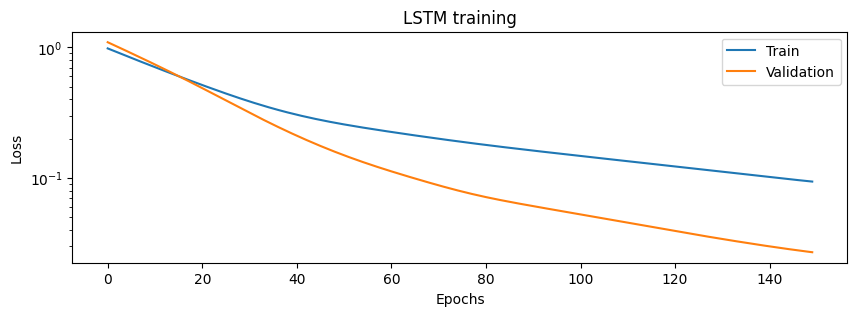

In [ ]:
plot_history(history, "LSTM training")

### **Exercise 2**
Investigate the model performance with different lags and number of hidden states. Discuss how the model looks and explain clearly how you tune the parameters and what the influence on the final prediction is. Which combination of parameters gives the best performance (MSE) on the test set?

Compare the results of the recurrent MLP with the LSTM. Which model do you prefer and why?

The MSE on the test set is: 3878.174


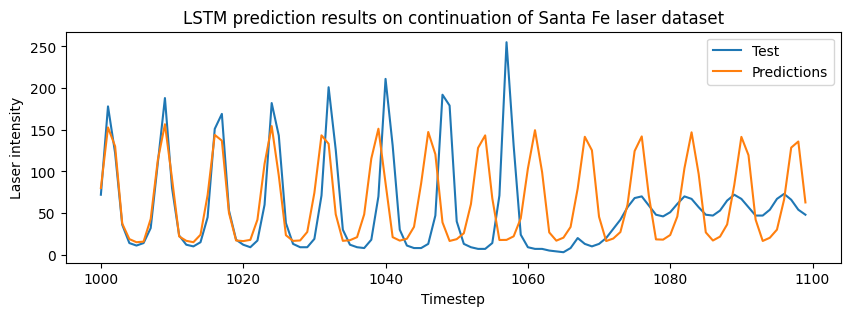

In [ ]:
# LSTM Evaluation
net.reset_states()
net.predict(data.reshape(1, -1, lag), verbose=0)
test_data = shift(data[-1], targets[-1])
predictions = np.empty(normalized_test.shape)
for t in range(len(predictions)):
  predictions[t] = net.predict(test_data.reshape((1, 1, lag)), verbose=0).squeeze()
  test_data = shift(test_data, predictions[t])

# Rescale predictions
predictions_lstm = rescale(predictions, params)

# Compute the mean squared error between the predictions and test set
mse = np.mean((test_series - predictions_lstm)**2)
print("The MSE on the test set is: {:.3f}".format(mse))

# Plot
plot_timeseries({"Test": (1000, test_series), "Predictions": (1000, predictions_lstm)}, "LSTM prediction results on continuation of Santa Fe laser dataset")

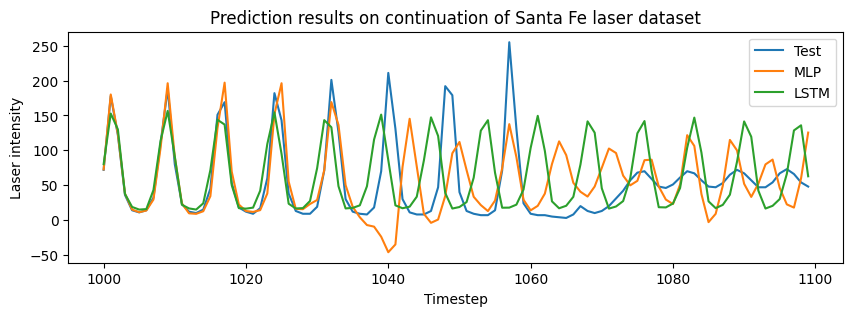

In [ ]:
# Comparison of both models
plot_timeseries({"Test": (1000, test_series), "MLP": (1000, predictions_mlp), "LSTM": (1000, predictions_lstm)}, "Prediction results on continuation of Santa Fe laser dataset")

### @solution
Training with the LSTM is much more consistent and results don't vary as much between different runs as was the case for the MLP. Good predictions can for example be obtained with hyperparameters $lag=20$ and $H=80$ (it should be able to correctly predict the 'drop', although the predictions can have a phase shift after this 'drop'), though other combinations might provide equally good results.

The MSE on the test set is: 224.357


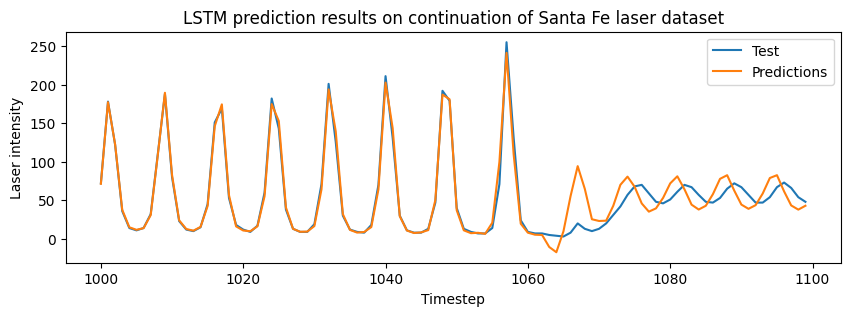

In [ ]:
# Train using "best" hyperparameters
lag, H = 20, 80
data, targets = prepare_timeseries(normalized, lag)
best_lstm = LSTM(lag, H, 1)
best_lstm.compile(
  loss=keras.losses.MeanSquaredError(),
  optimizer=keras.optimizers.Adam(learning_rate=0.001)
)
best_lstm.fit(
    data.reshape((1, -1, lag)), targets.reshape((1, -1)),
    epochs=150, callbacks=[LSTMCallback()], verbose=0)

# LSTM Evaluation on test set
best_lstm.reset_states()
best_lstm.predict(data.reshape(1, -1, lag), verbose=0)
test_data = shift(data[-1], targets[-1])
predictions = np.empty(normalized_test.shape)
for t in range(len(predictions)):
  predictions[t] = best_lstm.predict(test_data.reshape((1, 1, lag)), verbose=0).squeeze()
  test_data = shift(test_data, predictions[t])

# Rescale predictions
predictions_lstm = rescale(predictions, params)

# Compute the mean squared error between the predictions and test set
mse = np.mean((test_series - predictions_lstm)**2)
print("The MSE on the test set is: {:.3f}".format(mse))

# Plot
plot_timeseries({"Test": (1000, test_series), "Predictions": (1000, predictions_lstm)}, "LSTM prediction results on continuation of Santa Fe laser dataset")

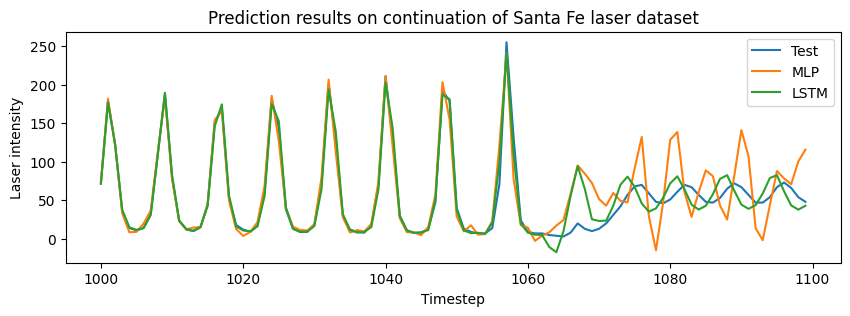

In [ ]:
# Comparison of both models
plot_timeseries({"Test": (1000, test_series), "MLP": (1000, predictions_mlp), "LSTM": (1000, predictions_lstm)}, "Prediction results on continuation of Santa Fe laser dataset")

---

## Exercise 5: Exploratory Data Analysis (EDA)

Before modelling, it is crucial to understand the temporal structure of each dataset. Below we provide EDA tools for the Santa Fe dataset and two additional datasets: Mackey-Glass and Sunspot Numbers.

In [ ]:
# === EDA Utility Functions ===

def plot_eda(series, title, window=50):
    """Comprehensive EDA for a time series."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Exploratory Data Analysis: {title}', fontsize=14, y=1.02)

    # Raw series with rolling statistics
    ax = axes[0, 0]
    ax.plot(series, linewidth=0.8, alpha=0.8, label='Raw')
    roll_mean = np.convolve(series, np.ones(window)/window, mode='valid')
    roll_std = np.array([np.std(series[max(0,i-window):i+1]) for i in range(len(series))])
    ax.plot(np.arange(window-1, len(series)), roll_mean, 'r-', linewidth=1.5, label=f'Rolling mean (w={window})')
    ax.fill_between(range(len(series)),
                     np.convolve(series, np.ones(window)/window, mode='same') - roll_std,
                     np.convolve(series, np.ones(window)/window, mode='same') + roll_std,
                     alpha=0.2, color='red', label='Rolling std')
    ax.set_title('Time Series with Rolling Statistics')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Distribution
    ax = axes[0, 1]
    ax.hist(series, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title('Value Distribution')
    ax.set_xlabel('Value')
    ax.grid(True, alpha=0.3)

    # ACF
    ax = axes[0, 2]
    max_lag = min(100, len(series) // 3)
    acf = np.correlate(series - np.mean(series), series - np.mean(series), mode='full')
    acf = acf[len(acf)//2:]
    acf = acf / acf[0]
    ax.bar(range(max_lag), acf[:max_lag], width=1.0, color='steelblue', alpha=0.7)
    ci = 1.96 / np.sqrt(len(series))
    ax.axhline(ci, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axhline(-ci, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title('Autocorrelation Function (ACF)')
    ax.set_xlabel('Lag')
    ax.grid(True, alpha=0.3)

    # PACF (approximation using Levinson-Durbin)
    ax = axes[1, 0]
    n_pacf = min(40, len(series) // 4)
    pacf_vals = np.zeros(n_pacf)
    pacf_vals[0] = 1.0
    for k in range(1, n_pacf):
        r = acf[:k+1]
        if k == 1:
            pacf_vals[k] = r[1] / r[0]
        else:
            toeplitz_mat = np.array([[acf[abs(i-j)] for j in range(k)] for i in range(k)])
            try:
                pacf_vals[k] = np.linalg.solve(toeplitz_mat, r[1:k+1])[-1]
            except np.linalg.LinAlgError:
                pacf_vals[k] = 0
    ax.bar(range(n_pacf), pacf_vals, width=1.0, color='coral', alpha=0.7)
    ax.axhline(ci, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axhline(-ci, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title('Partial Autocorrelation (PACF)')
    ax.set_xlabel('Lag')
    ax.grid(True, alpha=0.3)

    # Spectral density
    ax = axes[1, 1]
    from scipy.signal import periodogram
    freqs, psd = periodogram(series, fs=1.0)
    ax.semilogy(freqs[1:], psd[1:], color='steelblue', linewidth=0.8)
    ax.set_title('Power Spectral Density')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('PSD')
    ax.grid(True, alpha=0.3)

    # Summary statistics
    ax = axes[1, 2]
    ax.axis('off')
    stats_text = (
        f"Length: {len(series)}\n"
        f"Mean:  {np.mean(series):.4f}\n"
        f"Std:   {np.std(series):.4f}\n"
        f"Min:   {np.min(series):.4f}\n"
        f"Max:   {np.max(series):.4f}\n"
        f"Skew:  {float(scipy.stats.skew(series)):.4f}\n"
        f"Kurt:  {float(scipy.stats.kurtosis(series)):.4f}"
    )
    ax.text(0.1, 0.5, stats_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    ax.set_title('Summary Statistics')

    plt.tight_layout()
    return fig

from scipy import stats as scipy_stats
import scipy.stats

In [ ]:
# EDA for the Santa Fe Laser dataset
plot_eda(train_series, 'Santa Fe Laser')
plt.show()
print("\nInsight: The Santa Fe laser data shows strong short-range autocorrelation")
print("(ACF decays quickly) and local nonlinear structure. An MLP with appropriate")
print("lag can capture this well since all relevant info is in a short window.")

### Additional Dataset 1: Mackey-Glass Time Series

A chaotic delay differential equation with long-range dependencies (controlled by $\tau$).

In [ ]:
def generate_mackey_glass(tau=30, n_points=1500, beta=0.2, gamma=0.1, n=10, seed=42):
    """Generate the Mackey-Glass chaotic time series."""
    rng_mg = np.random.default_rng(seed)
    warmup = 500
    total = n_points + warmup + tau
    x = np.zeros(total)
    x[:tau] = 0.9 + 0.2 * (rng_mg.random(tau) - 0.5)
    for t in range(tau, total - 1):
        x[t + 1] = x[t] + beta * x[t - tau] / (1.0 + x[t - tau] ** n) - gamma * x[t]
    return x[warmup + tau: warmup + tau + n_points]

mg_tau = 30
mg_series = generate_mackey_glass(tau=mg_tau)
mg_train = mg_series[:1200]
mg_test = mg_series[1200:1400]

plt.figure(figsize=(14, 3))
plt.plot(mg_series, linewidth=0.8)
plt.axvline(x=1200, color='red', linestyle='--', label='Train/Test split')
plt.title(f'Mackey-Glass Time Series (tau={mg_tau})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plot_eda(mg_train, f'Mackey-Glass (tau={mg_tau})')
plt.show()
print(f"\nInsight: The Mackey-Glass series with tau={mg_tau} shows long-range autocorrelation")
print("(ACF stays significant for many lags). The system's current state depends on")
print(f"information from {mg_tau} steps ago, creating genuine long-range dependencies.")
print("LSTMs excel here because their gating mechanism preserves distant information.")

### Additional Dataset 2: Sunspot Numbers

Monthly sunspot counts with a quasi-periodic ~11-year cycle.

In [ ]:
import pandas as pd

try:
    sunspot_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
    sunspot_df = pd.read_csv(sunspot_url, header=0, names=['Month', 'Sunspots'])
    sunspot_series = sunspot_df['Sunspots'].values.astype(float)
except Exception:
    # Fallback: generate synthetic sunspot-like data
    t = np.arange(3000)
    sunspot_series = np.abs(50 * np.sin(2 * np.pi * t / 132) + 20 * np.sin(2 * np.pi * t / 66)
                            + 10 * np.random.randn(len(t)))
    print("Warning: Could not load sunspot data from URL. Using synthetic data.")

# Use last 1500 points for manageable training
sunspot_data = sunspot_series[-1500:]
ss_train = sunspot_data[:1200]
ss_test = sunspot_data[1200:1400]

plt.figure(figsize=(14, 3))
plt.plot(sunspot_data, linewidth=0.8)
plt.axvline(x=1200, color='red', linestyle='--', label='Train/Test split')
plt.title('Sunspot Numbers (monthly)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plot_eda(ss_train, 'Sunspot Numbers')
plt.show()
print("\nInsight: The sunspot data shows a clear ~11-year (132-month) periodicity in the")
print("spectral density and a slowly decaying ACF. A simple RNN can naturally track the")
print("phase of this cycle through its hidden state, without needing LSTM gating.")
print("MLPs would need a very large lag (>132) to capture the full cycle.")

---

## Exercise 4: Ablation Study Across Datasets

Train MLP, Simple RNN, and LSTM on all three datasets. Compare performance and relate to inductive biases.

### Simple RNN Definition

In [ ]:
def SimpleRNN_model(input_dim, hidden_dim, output_dim):
    """Simple RNN for time series prediction."""
    return keras.Sequential([
        keras.layers.SimpleRNN(hidden_dim, activation='tanh',
                                input_shape=(input_dim, 1),
                                return_sequences=False),
        keras.layers.Dense(output_dim)
    ])

def train_and_predict(model_fn, train_data, train_targets, test_len,
                      lag, hidden=32, epochs=100, lr=0.001,
                      is_recurrent=False, verbose=0):
    """Train a model and produce recursive predictions on the test set."""
    model = model_fn(lag, hidden, 1)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(learning_rate=lr))

    if is_recurrent:
        X_train = train_data.reshape(-1, lag, 1)
    else:
        X_train = train_data

    history = model.fit(X_train, train_targets, epochs=epochs,
                        validation_split=0.15, verbose=verbose)

    # Recursive prediction
    if is_recurrent:
        if hasattr(model, 'reset_states'):
            try:
                model.reset_states()
            except Exception:
                pass
        window = train_data[-1].copy()
        predictions = np.empty(test_len)
        for t in range(test_len):
            inp = window.reshape(1, lag, 1)
            pred = float(model.predict(inp, verbose=0).flatten()[0])
            predictions[t] = pred
            window = shift(window, pred)
    else:
        window = train_data[-1].copy()
        predictions = np.empty(test_len)
        for t in range(test_len):
            pred = float(model.predict(window.reshape(1, -1), verbose=0).flatten()[0])
            predictions[t] = pred
            window = shift(window, pred)

    return model, history, predictions

### Ablation Study: Training All Models on All Datasets

This cell trains MLP, Simple RNN, and LSTM on Santa Fe, Mackey-Glass, and Sunspot data. Adjust `lag`, `epochs`, and `hidden` as needed.

In [ ]:
ablation_lag = 20
ablation_hidden = 32
ablation_epochs = 150

# Use santafe['A'] / santafe['Acont'] directly.
# The variable `train_series` is overwritten by the cross-validation fold
# visualisation loop above (it becomes a concat of a Hankel row + fold targets),
# which would cause double-normalisation here and produce flat predictions.
datasets = {
    'Santa Fe': (santafe['A'], santafe['Acont']),
    'Mackey-Glass': (mg_train, mg_test),
    'Sunspot': (ss_train, ss_test),
}

model_fns = {
    'MLP': (lambda lag, h, o: keras.Sequential([
        keras.layers.Dense(h, activation='tanh', input_shape=(lag,)),
        keras.layers.Dense(o)
    ]), False),
    'SimpleRNN': (SimpleRNN_model, True),
    'LSTM': (lambda lag, h, o: keras.Sequential([
        keras.layers.LSTM(h, input_shape=(lag, 1)),
        keras.layers.Dense(o)
    ]), True),
}

results = {}
all_predictions = {}

for ds_name, (train_raw, test_raw) in datasets.items():
    print(f"\n{'='*60}")
    print(f"  Dataset: {ds_name}")
    print(f"{'='*60}")

    norm_train, ds_params = normalize(train_raw)
    norm_test, _ = normalize(test_raw, ds_params)
    ds_data, ds_targets = prepare_timeseries(norm_train, ablation_lag)
    test_len = len(test_raw)

    for model_name, (model_fn, is_rec) in model_fns.items():
        print(f"  Training {model_name}...", end=' ', flush=True)
        try:
            _, hist, preds = train_and_predict(
                model_fn, ds_data, ds_targets, test_len,
                lag=ablation_lag, hidden=ablation_hidden,
                epochs=ablation_epochs, is_recurrent=is_rec, verbose=0
            )
            preds_rescaled = rescale(preds, ds_params)
            mse = float(np.mean((preds_rescaled - test_raw[:test_len]) ** 2))
            mae = float(np.mean(np.abs(preds_rescaled - test_raw[:test_len])))
            results[(ds_name, model_name)] = {'MSE': mse, 'MAE': mae}
            all_predictions[(ds_name, model_name)] = preds_rescaled
            print(f"MSE = {mse:.4f}, MAE = {mae:.4f}")
        except Exception as e:
            print(f"FAILED: {e}")
            results[(ds_name, model_name)] = {'MSE': float('inf'), 'MAE': float('inf')}

print("\nTraining complete!")

### Results: Summary Table and Prediction Plots

In [ ]:
# Summary table
print("\n" + "=" * 70)
print(f"{'Dataset':<15} {'Model':<12} {'MSE':>12} {'MAE':>12}  {'Best?':>6}")
print("=" * 70)

for ds_name in datasets:
    ds_results = {m: results[(ds_name, m)] for m in model_fns}
    best_model = min(ds_results, key=lambda m: ds_results[m]['MSE'])
    for model_name in model_fns:
        r = results[(ds_name, model_name)]
        marker = " <---" if model_name == best_model else ""
        print(f"{ds_name:<15} {model_name:<12} {r['MSE']:>12.4f} {r['MAE']:>12.4f}{marker}")
    print("-" * 70)

print("\nExpected winners:")
print("  Santa Fe    -> MLP       (strong local structure)")
print("  Sunspot     -> SimpleRNN (moderate periodic dependencies)")
print("  Mackey-Glass-> LSTM      (long-range chaotic dependencies)")

In [ ]:
# Prediction overlay plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = {'MLP': '#e74c3c', 'SimpleRNN': '#3498db', 'LSTM': '#2ecc71'}

for idx, (ds_name, (_, test_raw)) in enumerate(datasets.items()):
    ax = axes[idx]
    test_len = len(test_raw)
    ax.plot(test_raw[:test_len], 'k-', linewidth=2, label='Ground Truth', alpha=0.8)
    for model_name in model_fns:
        key = (ds_name, model_name)
        if key in all_predictions:
            ax.plot(all_predictions[key], '--', linewidth=1.2,
                    color=colors[model_name], label=model_name, alpha=0.8)
    ax.set_title(f'{ds_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Predictions vs Ground Truth (All Datasets)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Residual analysis and error distributions
fig, axes = plt.subplots(2, 3, figsize=(20, 8))

for idx, (ds_name, (_, test_raw)) in enumerate(datasets.items()):
    test_len = len(test_raw)
    # Residuals
    ax_r = axes[0, idx]
    for model_name in model_fns:
        key = (ds_name, model_name)
        if key in all_predictions:
            residuals = test_raw[:test_len] - all_predictions[key]
            ax_r.plot(residuals, linewidth=0.8, color=colors[model_name],
                     label=model_name, alpha=0.7)
    ax_r.axhline(0, color='black', linewidth=0.5)
    ax_r.set_title(f'{ds_name}: Residuals')
    ax_r.legend(fontsize=7)
    ax_r.grid(True, alpha=0.3)

    # Error distributions
    ax_h = axes[1, idx]
    for model_name in model_fns:
        key = (ds_name, model_name)
        if key in all_predictions:
            errors = test_raw[:test_len] - all_predictions[key]
            ax_h.hist(errors, bins=30, alpha=0.5, color=colors[model_name],
                     label=model_name, density=True)
    ax_h.set_title(f'{ds_name}: Error Distribution')
    ax_h.legend(fontsize=7)
    ax_h.grid(True, alpha=0.3)

fig.suptitle('Residual Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# MSE comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ds_names = list(datasets.keys())
model_names = list(model_fns.keys())
x = np.arange(len(ds_names))
width = 0.25

for i, model_name in enumerate(model_names):
    mse_vals = [results[(ds, model_name)]['MSE'] for ds in ds_names]
    bars = ax.bar(x + i * width, mse_vals, width, label=model_name,
                  color=colors[model_name], alpha=0.8, edgecolor='white')
    # Highlight best for each dataset
    for j, ds in enumerate(ds_names):
        best = min(model_names, key=lambda m: results[(ds, m)]['MSE'])
        if model_name == best:
            bars[j].set_edgecolor('gold')
            bars[j].set_linewidth(2.5)

ax.set_xlabel('Dataset')
ax.set_ylabel('Test MSE')
ax.set_title('Model Comparison: Test MSE by Dataset')
ax.set_xticks(x + width)
ax.set_xticklabels(ds_names)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("\nGold-bordered bars indicate the best model for each dataset.")
print("This visualization directly shows how inductive biases match data characteristics.")